# Make your own least squares methods!

In [1]:
#imports
import numpy as np
import matplotlib.pyplot as plt
import random

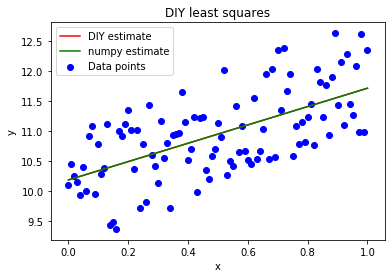

true - m:2 c:10
DIY - m:1.533452705893785 c:10.182921181469897
np - m:1.5334527058937777 c:10.182921181469903


In [2]:
def leastsqr(x,y):
    #sumations
    sum_x = np.sum(x)
    sum_y = np.sum(y)
    sum_x2 = np.sum(x*x)
    sum_xy = np.sum(x*y)
    
    #calculate
    n = np.size(x)
    m = (n* sum_xy - sum_x*sum_y) / (n*sum_x2 - sum_x**2)
    c = (sum_y - m*sum_x)/n
    
    return m,c

np.random.seed(0)

#make points
# y = 2x+10 is what this is going to be based on
m_true = 2
c_true =10
x = np.arange(0, 1.01, 0.01)
x = np.sort(x)
noise = np.random.uniform(-1.0, 1.0, len(x))
y = m_true* x + c_true + noise

#use diy
m,c = leastsqr(x,y)
y_est_diy = m*x + c

#use numpy
A = np.vstack([x, np.ones(len(x))]).T
m2, c2 = np.linalg.lstsq(A, y, rcond=None)[0]
y_est_np = m2*x + c2

#plot
plt.scatter(x, y, color='blue', label='Data points') # Original data points
plt.plot(x, y_est_diy, color='red', label=f'DIY estimate')
plt.plot(x, y_est_np, color='green', label=f'numpy estimate')

plt.title('DIY least squares')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

print(f"true - m:{m_true} c:{c_true}")
print(f'DIY - m:{m} c:{c}')
print(f'np - m:{m2} c:{c2}')

In [3]:
print("DIY error analyisis: ")

#calculate residuals
res_DIY = y - y_est_diy
small_DIY = np.argmin(np.abs(res_DIY))
big_DIY = np.argmax(np.abs(res_DIY))

#print out importants values
print("first couple residuals:")
print(res_DIY[:10])
print("smallest res")
print("x =", x[small_DIY], "y =", y[small_DIY], "res =", res_DIY[small_DIY])
print("big res")
print("x =", x[big_DIY], "y =", y[big_DIY], "res =", res_DIY[big_DIY])


print()
print()

#calculate residuals
print("numpy error analyisis: ")
res_np = y - y_est_np
small_np = np.argmin(np.abs(res_np))
big_np = np.argmax(np.abs(res_np))

#print out important values
print("first couple residuals:")
print(res_np[:10])
print("smallest res")
print("x =", x[small_np], "y =", y[small_np], "res =", res_np[small_np])
print("big res")
print("x =", x[big_np], "y =", y[big_np], "res =", res_np[big_np])



DIY error analyisis: 
first couple residuals:
[-0.08529417  0.25212302  0.03193652 -0.0791584  -0.31694969  0.13219441
 -0.27975392  0.63328313  0.78172812 -0.37404889]
smallest res
x = 0.28 y = 10.603696643500143 res = -0.008591295620014705
big res
x = 0.72 y = 12.393522176380674 res = 1.1065150466672513


numpy error analyisis: 
first couple residuals:
[-0.08529417  0.25212302  0.03193652 -0.0791584  -0.31694969  0.13219441
 -0.27975392  0.63328313  0.78172812 -0.37404889]
smallest res
x = 0.28 y = 10.603696643500143 res = -0.008591295620016481
big res
x = 0.72 y = 12.393522176380674 res = 1.1065150466672513
